<a href="https://colab.research.google.com/github/RitaLB/Stonelab-Churn-Clientes-AI/blob/main/notebooks/stone_churn_clients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pré processamento

## **Carregamento dos dados e pré processamento**

In [102]:
import urllib.request, csv, io
from pathlib import Path
import pandas as pd, numpy as np

URL = "https://raw.githubusercontent.com/RitaLB/Stonelab-Churn-Clientes-AI/main/data/dataset-churn.csv"

# Quando o notebook roda dentro de notebooks/, os dados ficam em ../data.
# Quando roda na raiz do projeto, os dados ficam em data/.
DATA_DIR = Path("../data") if (Path("../data") / "dataset-churn.csv").exists() else Path("data")


def carregar_texto(nome_arquivo, url):
    """Lê arquivo local em DATA_DIR; caso contrário, baixa pela URL raw."""
    caminho = DATA_DIR / nome_arquivo
    if caminho.exists():
        return caminho.read_text(encoding="utf-8")
    return urllib.request.urlopen(url).read().decode("utf-8")


# Dataset original.
raw = list(csv.reader(io.StringIO(carregar_texto("dataset-churn.csv", URL))))
header, linhas = raw[0], raw[1:]
n_cols = len(header)
print(f"Pasta de dados: {DATA_DIR.resolve()}")
print(n_cols)


15


Upload Schema para tipagem das colunas - Segundo Dicionário de dados

In [103]:
import json
SCHEMA_URL = "https://raw.githubusercontent.com/RitaLB/Stonelab-Churn-Clientes-AI/main/data/schema_churn.json"
schema = json.loads(carregar_texto("schema_churn.json", SCHEMA_URL))


Diagnostico de corretude do database

In [104]:
def validar(linhas, header, schema):
    """Valida cada célula contra o schema (fonte da verdade do dicionário).
    Retorna {num_linha: {coluna: motivo}} contendo apenas as violações."""

    def ok_tipo(v, t):
        # int: apenas dígitos (aceita sinal negativo). float: converte para número.
        # categorica/string/binaria não checam tipo aqui — são validadas pelo domínio.
        if t == "int":   return v.lstrip("-").isdigit()
        if t == "float": return pd.notna(pd.to_numeric([v], errors="coerce")[0])
        return True

    def ok_dominio(v, d):
        if not d:                      # coluna sem domínio definido (ex: id)
            return True
        if "valores" in d:             # categórica: valor deve estar na lista permitida
            return v in d["valores"]
        n = pd.to_numeric([v], errors="coerce")[0]   # numérica: checa faixa min/max
        if pd.isna(n):
            return False
        return ("min" not in d or n >= d["min"]) and ("max" not in d or n <= d["max"])

    erros = {}
    for i, r in enumerate(linhas, 1):
        # 1) Falha estrutural: nº de campos diferente do cabeçalho.
        #    Impede alinhar coluna↔valor, então a linha é reportada sem checagem célula a célula.
        if len(r) != len(header):
            erros[i] = {"_estrutural": f"{len(r)} campos (esperado {len(header)})"}
            continue

        # 2) Linha alinhada: valida cada célula na ordem tipo -> domínio.
        linha_erros = {}
        for col, v in zip(header, r):
            if v == "":                                      # valor ausente
                linha_erros[col] = "vazio"
            elif not ok_tipo(v, schema[col]["tipo"]):        # tipo incompatível
                linha_erros[col] = f"tipo!={schema[col]['tipo']}"
            elif not ok_dominio(v, schema[col]["dominio"]):  # fora do domínio permitido
                linha_erros[col] = "fora do dominio"
        if linha_erros:
            erros[i] = linha_erros

    return erros


erros = validar(linhas, header, schema)
erros

{5: {'plano': 'vazio'},
 17: {'nps_ultimo': 'vazio'},
 27: {'_estrutural': '16 campos (esperado 15)'}}

Correção erro estrutural

In [105]:
from itertools import combinations

def corrigir_estrutural(r, header, schema):
    """Corrige linha com campos a mais. Só remove campos VAZIOS, e aceita a
    correção apenas se a linha resultante for válida no schema. Isso distingue
    vazio espúrio (vírgula extra) de vazio legítimo (faltante real)."""
    n = len(header)

    # Linha já alinhada: nada a corrigir.
    if len(r) == n:
        return r, None

    excesso = len(r) - n                              # quantos campos sobram
    pos_vazias = [k for k, v in enumerate(r) if v == ""]  # posições vazias candidatas

    # Se os campos extras não são vazios, não é vírgula espúria — não corrigimos.
    if len(pos_vazias) < excesso:
        return None, "campos extras nao sao vazios"

    # Testa cada combinação de campos vazios a remover.
    # A remoção correta realinha os valores nas colunas certas; a errada
    # desloca valores e gera erro de tipo/domínio na validação.
    for pos in combinations(pos_vazias, excesso):
        cand = [v for k, v in enumerate(r) if k not in pos]
        erros = validar([cand], header, schema).get(1, {})

        # Aceita só se os erros restantes forem apenas "vazio" (faltantes
        # legítimos, tratados na imputação). Qualquer erro de tipo/domínio
        # significa desalinhamento → candidata rejeitada.
        if all(m == "vazio" for m in erros.values()):
            return cand, None

    return None, "nenhuma remocao produz linha valida"

# Aplica correção estrutural
linhas_corrigidas, descartes = [], []
for i, r in enumerate(linhas, 1):
    c, motivo = corrigir_estrutural(r, header, schema)
    linhas_corrigidas.append(c) if c is not None else descartes.append((i, motivo))

# Converte "" -> None (faltantes legítimos, tratados na imputação)
dados = [[None if v == "" else v for v in r] for r in linhas_corrigidas]

# Confirmação: nenhum erro estrutural/tipo/domínio deve restar (apenas "vazio")
erros_finais = validar(linhas_corrigidas, header, schema)
erros_finais

{5: {'plano': 'vazio'}, 17: {'nps_ultimo': 'vazio'}}

Salvar tabela pré-processada


In [106]:
import csv

caminho_corrigido = DATA_DIR / "dataset-churn-corrigido.csv"
caminho_corrigido.parent.mkdir(exist_ok=True)

with caminho_corrigido.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(header)
    w.writerows(dados)

print(f"Dataset corrigido salvo em: {caminho_corrigido.resolve()}")


# 4.1 Representação do Conhecimento

**Fonte da verdade para tipos e domínios:** dicionário de dados (schema_churn.json).

**Transformações pré-EDA** (preparam o dado para ser analisado, sem alterar distribuições):



*   **Descarte de cliente_id** — remoção de coluna. Identificador único, sem poder preditivo.

*   **Tipagem conforme schema** (Int64, float, string) : conversão de tipo. Int64 preserva NaN em colunas inteiras.


**Transformações pós-EDA** (aplicadas após entender o dado, alimentam o modelo):


*   **Imputação** : preenche faltantes: mediana (numéricas, robusta a outliers), moda (categóricas).

*   **One-Hot Encoding** : converte categórica em colunas binárias (0/1) por categoria. Evita impor ordem inexistente.

* **Padronização** (z-score) : reescala numéricas para média 0 e desvio 1. Evita que features de escala grande (TPV) dominem as de escala pequena (NPS).




Transformações pré-EDA:


In [107]:
import pandas as pd

# 1. DataFrame tipado conforme schema
df = pd.DataFrame(dados, columns=header)
for col, spec in schema.items():
    if spec["tipo"] in ("int", "binaria"):
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    elif spec["tipo"] == "float":
        df[col] = pd.to_numeric(df[col], errors="coerce")
    else:
        df[col] = df[col].astype("string")

# 2. Descarte de identificador
df = df.drop(columns=["cliente_id"])

# 3. Separação por papel (imputação/encoding aplicados após a EDA)
alvo = "churn"
num_cols = [c for c, s in schema.items()
            if s["tipo"] in ("int", "float") and s.get("usar_como_feature")]
cat_cols = [c for c, s in schema.items()
            if s["tipo"] == "categorica" and s.get("usar_como_feature")]

In [108]:
# Teste se transformação deu certo

In [109]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum()[lambda s: s > 0])

(30, 14)
tpv_medio_mensal                 int64
variacao_tpv_3m                float64
dias_sem_transacao               Int64
tempo_cliente_meses              Int64
num_produtos_ativos              Int64
ticket_medio                   float64
num_chamados_suporte             Int64
nps_ultimo                       Int64
segmento                string[python]
regiao                  string[python]
tem_maquininha          string[python]
plano                   string[python]
usa_app_mobile          string[python]
churn                            Int64
dtype: object
nps_ultimo    1
plano         1
dtype: int64


# 4.2 — Análise Exploratória (EDA)

Aqui analisamos a base antes de treinar os modelos. A ideia é ver se existem valores faltantes, se as classes estão balanceadas, como as variáveis se comportam e quais delas parecem ter relação com churn.


## 4.2.1 Visão geral, faltantes e balanceamento

Primeiro verificamos tamanho da base, tipos de variáveis, valores ausentes e proporção do alvo `churn`. Isso orienta as próximas escolhas: imputação, métricas e necessidade de lidar com classe minoritária.


In [110]:
# Resumo estrutural do dataset depois das correções da etapa 4.1
print(f"Linhas: {df.shape[0]}")
print(f"Colunas usadas em df: {df.shape[1]}")
print(f"Features numéricas: {len(num_cols)} -> {num_cols}")
print(f"Features categóricas: {len(cat_cols)} -> {cat_cols}")

resumo_tipos = pd.DataFrame({
    "coluna": df.columns,
    "tipo": [str(df[c].dtype) for c in df.columns],
    "ausentes": [int(df[c].isna().sum()) for c in df.columns],
    "unicos": [int(df[c].nunique(dropna=True)) for c in df.columns],
})
display(resumo_tipos)


Linhas: 30
Colunas usadas em df: 14
Features numéricas: 8 -> ['tpv_medio_mensal', 'variacao_tpv_3m', 'dias_sem_transacao', 'tempo_cliente_meses', 'num_produtos_ativos', 'ticket_medio', 'num_chamados_suporte', 'nps_ultimo']
Features categóricas: 5 -> ['segmento', 'regiao', 'tem_maquininha', 'plano', 'usa_app_mobile']


,coluna,tipo,ausentes,unicos
0,tpv_medio_mensal,int64,0,30
1,variacao_tpv_3m,float64,0,30
2,dias_sem_transacao,Int64,0,20
3,tempo_cliente_meses,Int64,0,28
4,num_produtos_ativos,Int64,0,4
5,ticket_medio,float64,0,30
6,num_chamados_suporte,Int64,0,9
7,nps_ultimo,Int64,1,10
8,segmento,string,0,3
9,regiao,string,0,5


In [111]:
# Faltantes por coluna: modelos não aceitam vazio, então isto justifica imputação na etapa de modelagem.
faltantes = df.isna().sum().sort_values(ascending=False)
faltantes = faltantes[faltantes > 0].to_frame("quantidade")
faltantes["percentual"] = (faltantes["quantidade"] / len(df) * 100).round(1)
display(faltantes if not faltantes.empty else "Não há valores ausentes.")

# Distribuição absoluta e percentual da classe alvo.
classe = df[alvo].value_counts(dropna=False).sort_index().rename(index={0: "ativo (0)", 1: "churn (1)"})
classe_pct = (df[alvo].value_counts(normalize=True, dropna=False).sort_index() * 100).rename(index={0: "ativo (0)", 1: "churn (1)"})
balanceamento = pd.concat([classe.rename("quantidade"), classe_pct.round(1).rename("percentual")], axis=1)
display(balanceamento)


,quantidade,percentual
plano,1,3.3
nps_ultimo,1,3.3


,quantidade,percentual
churn,,
ativo (0),19,63.3
churn (1),11,36.7


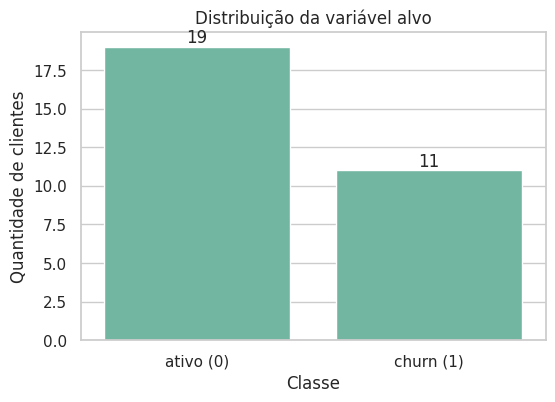

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")

fig, ax = plt.subplots(figsize=(6, 4))
plot_df = df.copy()
plot_df["classe"] = plot_df[alvo].map({0: "ativo (0)", 1: "churn (1)"})
sns.countplot(data=plot_df, x="classe", order=["ativo (0)", "churn (1)"], ax=ax)
ax.set_title("Distribuição da variável alvo")
ax.set_xlabel("Classe")
ax.set_ylabel("Quantidade de clientes")
for container in ax.containers:
    ax.bar_label(container)
plt.show()


**Comentário:** Existem mais clientes ativos do que clientes com churn. Por isso, só olhar acurácia pode enganar: um modelo pode acertar muitos ativos e ainda assim errar os churns.


## 4.2.2 Distribuições numéricas por classe

Agora comparamos as variáveis numéricas entre clientes ativos e clientes que churnaram. As visualizações mostram diferença de localização, dispersão e possíveis valores extremos.


In [113]:
# Estatísticas descritivas por classe para as variáveis numéricas.
estatisticas_por_classe = df.groupby(alvo)[num_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
estatisticas_por_classe = estatisticas_por_classe.rename(columns={0: "ativo (0)", 1: "churn (1)"})
display(estatisticas_por_classe.round(2))


churn                           ativo (0)    churn (1)
tpv_medio_mensal     count             19           11
                     mean    38631.578947  9318.181818
                     median       35000.0       8000.0
                     std     22091.251477   3125.96167
                     min            11000         6500
                     max            82000        15000
variacao_tpv_3m      count             19           11
                     mean       -0.041053    -0.460909
                     median         -0.05        -0.48
                     std         0.128448     0.103291
                     min            -0.28         -0.6
                     max             0.15         -0.3
dias_sem_transacao   count             19           11
                     mean        3.631579    19.363636
                     median           3.0         20.0
                     std         2.629122     5.239709
                     min                1           12
                     max               10           28
tempo_cliente_meses  count             19           11
                     mean       33.368421     7.363636
                     median          32.0          6.0
                     std        15.801584     3.905707
                     min               10            3
                     max               66           14
num_produtos_ativos  count             19           11
                     mean        2.789474          1.0
                     median           3.0          1.0
                     std         0.787327          0.0
                     min                2            1
                     max                4            1
ticket_medio         count             19           11
                     mean       83.789474    32.363636
                     median          75.0         30.0
                     std        35.594286      8.06564
                     min             40.0         22.0
                     max            160.0         45.0
num_chamados_suporte count             19           11
                     mean        1.421053     5.636364
                     median           1.0          6.0
                     std         1.070607     1.361817
                     min                0            4
                     max                3            8
nps_ultimo           count             19           10
                     mean        7.842105          2.6
                     median           8.0          2.5
                     std         1.740471     1.173788
                     min                5            1
                     max               10            4

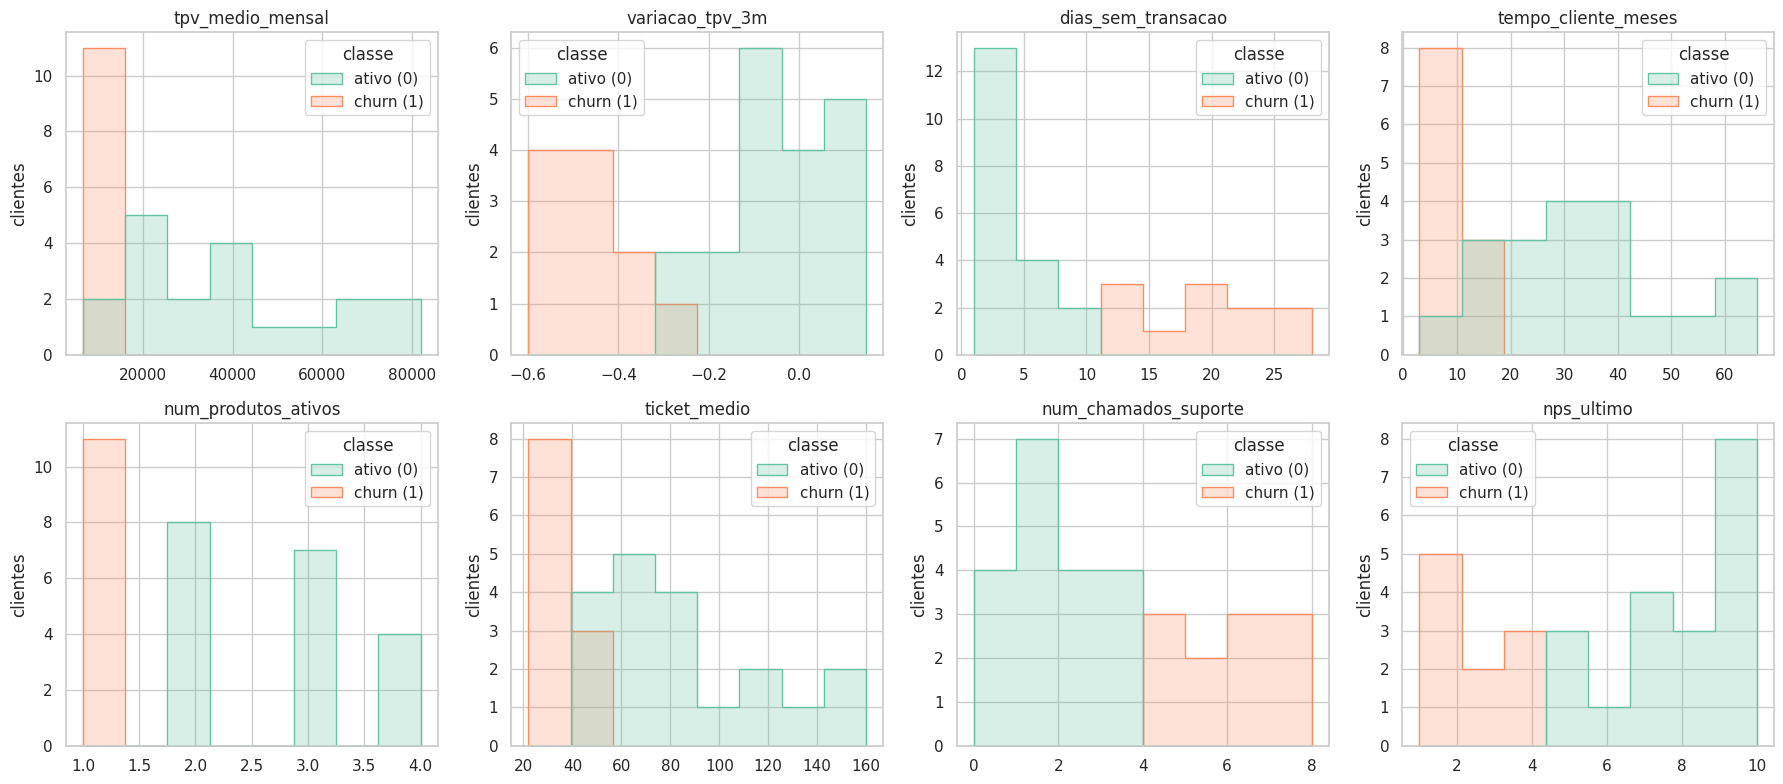

In [114]:
# Histogramas: ajudam a ver a concentração de valores em cada classe.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(data=plot_df, x=col, hue="classe", bins=8, kde=False, element="step", stat="count", common_norm=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("clientes")
plt.tight_layout()
plt.show()


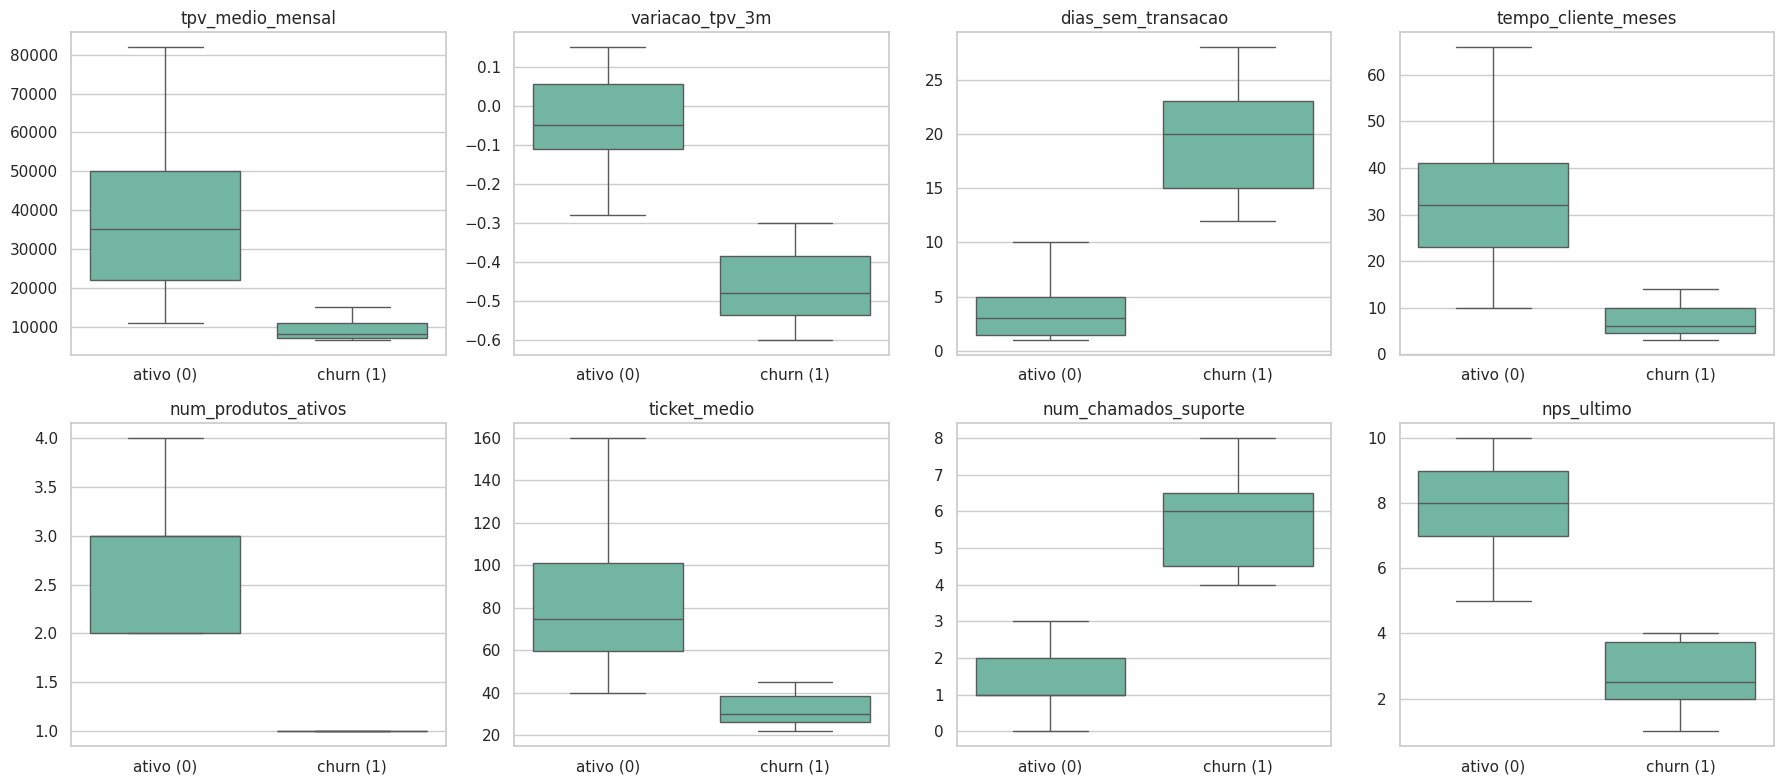

In [115]:
# Boxplots: evidenciam medianas, dispersão e outliers por classe.
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=plot_df, x="classe", y=col, order=["ativo (0)", "churn (1)"], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


**Comentário:** Os clientes com churn parecem ter mais dias sem transação, mais chamados de suporte, maior queda no TPV, NPS menor e menos produtos ativos.


## 4.2.3 Outliers

A análise de outliers usa a regra do intervalo interquartil (IQR). Outlier não significa erro automaticamente, a decisão mais segura é documentar os extremos e deixar modelos/transformações lidarem com eles.


In [116]:
def resumo_outliers_iqr(dataframe, colunas):
    linhas_outliers = []
    for col in colunas:
        serie = dataframe[col].dropna().astype(float)
        q1 = serie.quantile(0.25)
        q3 = serie.quantile(0.75)
        iqr = q3 - q1
        limite_inf = q1 - 1.5 * iqr
        limite_sup = q3 + 1.5 * iqr
        qtd = int(((serie < limite_inf) | (serie > limite_sup)).sum())
        linhas_outliers.append({
            "variavel": col,
            "q1": q1,
            "q3": q3,
            "limite_inferior": limite_inf,
            "limite_superior": limite_sup,
            "qtd_outliers": qtd,
        })
    return pd.DataFrame(linhas_outliers)

outliers_iqr = resumo_outliers_iqr(df, num_cols)
display(outliers_iqr.round(2))


,variavel,q1,q3,limite_inferior,limite_superior,qtd_outliers
0,tpv_medio_mensal,9500.00,39500.00,-35500.00,84500.00,0
1,variacao_tpv_3m,-0.40,0.03,-1.05,0.67,0
2,dias_sem_transacao,2.25,15.50,-17.62,35.38,0
3,tempo_cliente_meses,8.50,35.50,-32.00,76.00,0
4,num_produtos_ativos,1.00,3.00,-2.00,6.00,0
5,ticket_medio,36.25,79.50,-28.62,144.38,2
6,num_chamados_suporte,1.00,4.75,-4.62,10.38,0
7,nps_ultimo,4.00,9.00,-3.50,16.50,0


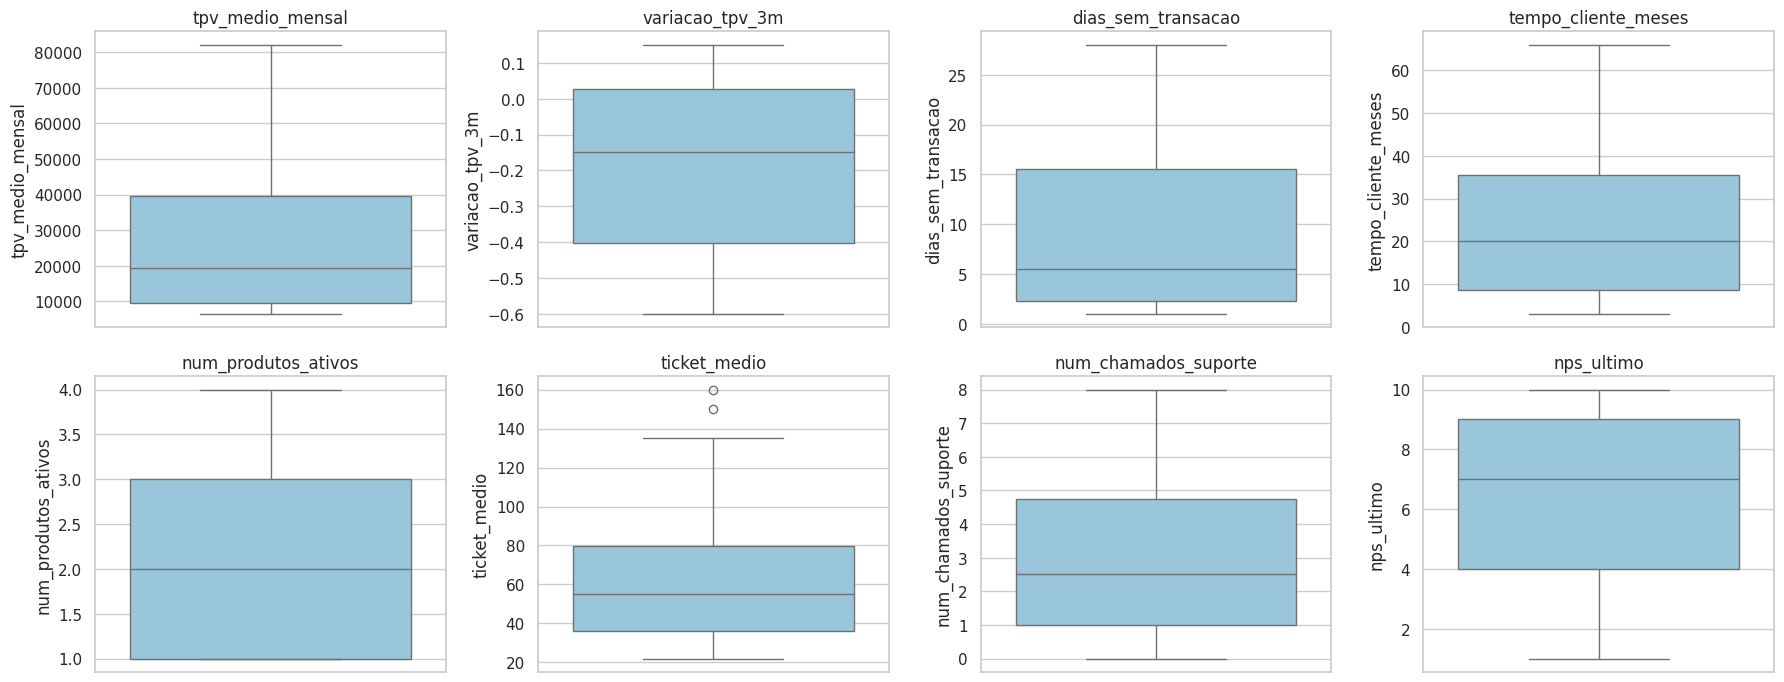

In [117]:
# Visão compacta da escala e dos possíveis extremos numéricos.
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df, y=col, ax=ax, color="#8ecae6")
    ax.set_title(col)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


**Comentário:** Alguns valores podem parecer extremos, mas não vou remover automaticamente. Como a base é pequena, tirar linhas pode atrapalhar mais do que ajudar. Melhor manter os dados e tratar isso na modelagem.


## 4.2.4 Correlações com churn

A correlação mostra quais variáveis numéricas parecem andar junto com o churn. Ela não prova causa, mas ajuda a levantar hipóteses.


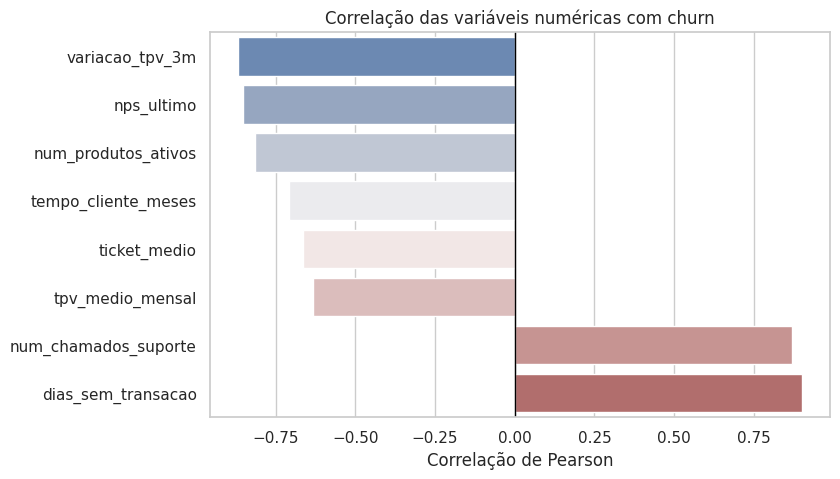

,correlacao_com_churn
variacao_tpv_3m,-0.868
nps_ultimo,-0.854
num_produtos_ativos,-0.816
tempo_cliente_meses,-0.710
ticket_medio,-0.663
tpv_medio_mensal,-0.635
num_chamados_suporte,0.872
dias_sem_transacao,0.901


In [118]:
# Correlação das variáveis numéricas com churn.
corr_churn = df[num_cols + [alvo]].astype(float).corr(numeric_only=True)[alvo].drop(alvo).sort_values()
corr_plot = corr_churn.reset_index()
corr_plot.columns = ["variavel", "correlacao"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=corr_plot, x="correlacao", y="variavel", hue="variavel", palette="vlag", legend=False, ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Correlação das variáveis numéricas com churn")
ax.set_xlabel("Correlação de Pearson")
ax.set_ylabel("")
plt.show()

display(corr_churn.to_frame("correlacao_com_churn").round(3))


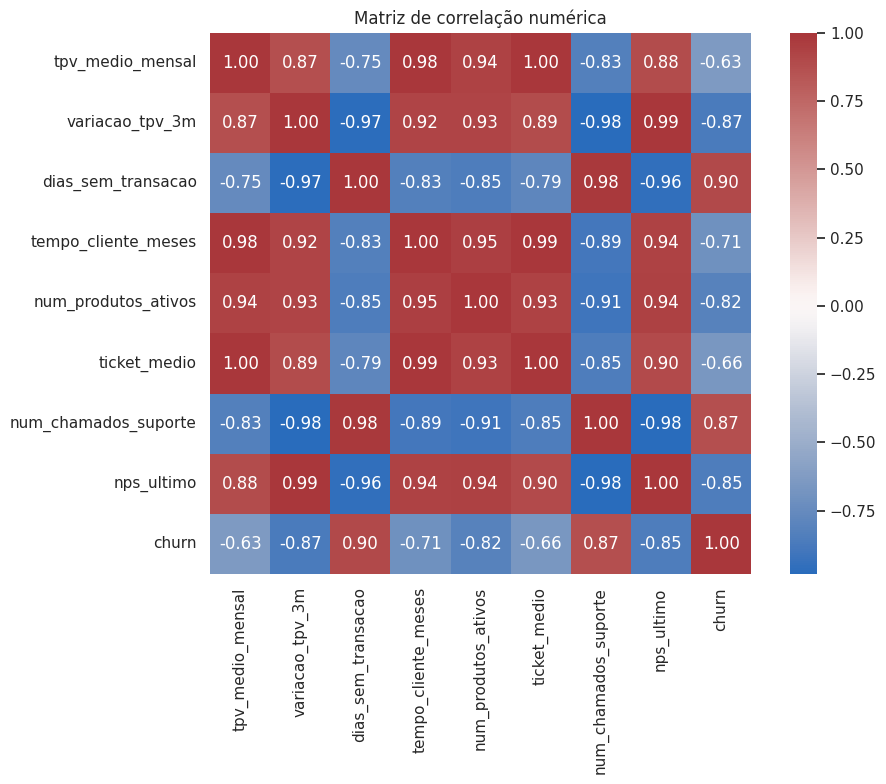

In [119]:
# Matriz de correlação completa das numéricas, incluindo o alvo.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[num_cols + [alvo]].astype(float).corr(), annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Matriz de correlação numérica")
plt.tight_layout()
plt.show()


**Comentário:** correlação positiva indica que a variável aumenta junto com churn. Correlação negativa indica o contrário. Aqui, mais dias sem transação e mais chamados parecem aumentar o risco; NPS, TPV e produtos ativos maiores parecem reduzir o risco.


## 4.2.5 Variáveis categóricas por classe

As variáveis categóricas ajudam a verificar se segmento, região, plano, maquininha e uso do app aparecem com perfis diferentes entre ativos e churn.


In [120]:
# Tabelas percentuais: para cada categoria, qual a distribuição entre ativo e churn.
cat_eda = df.copy()
for col in cat_cols:
    cat_eda[col] = cat_eda[col].astype("object").where(cat_eda[col].notna(), "não informado")

for col in cat_cols:
    tabela = pd.crosstab(cat_eda[col], cat_eda[alvo], normalize="index") * 100
    tabela = tabela.rename(columns={0: "ativo_%", 1: "churn_%"}).round(1)
    print("\n" + col)
    display(tabela)



segmento


churn,ativo_%,churn_%
segmento,,
basico,20.0,80.0
premium,100.0,0.0
standard,70.0,30.0



regiao


churn,ativo_%,churn_%
regiao,,
centro-oeste,100.0,0.0
nordeste,11.1,88.9
norte,0.0,100.0
sudeste,100.0,0.0
sul,100.0,0.0



tem_maquininha


churn,ativo_%,churn_%
tem_maquininha,,
nao,0.0,100.0
sim,76.0,24.0



plano


churn,ativo_%,churn_%
plano,,
avancado,100.0,0.0
basico,16.7,83.3
intermediario,100.0,0.0
não informado,0.0,100.0



usa_app_mobile


churn,ativo_%,churn_%
usa_app_mobile,,
nao,21.4,78.6
sim,100.0,0.0


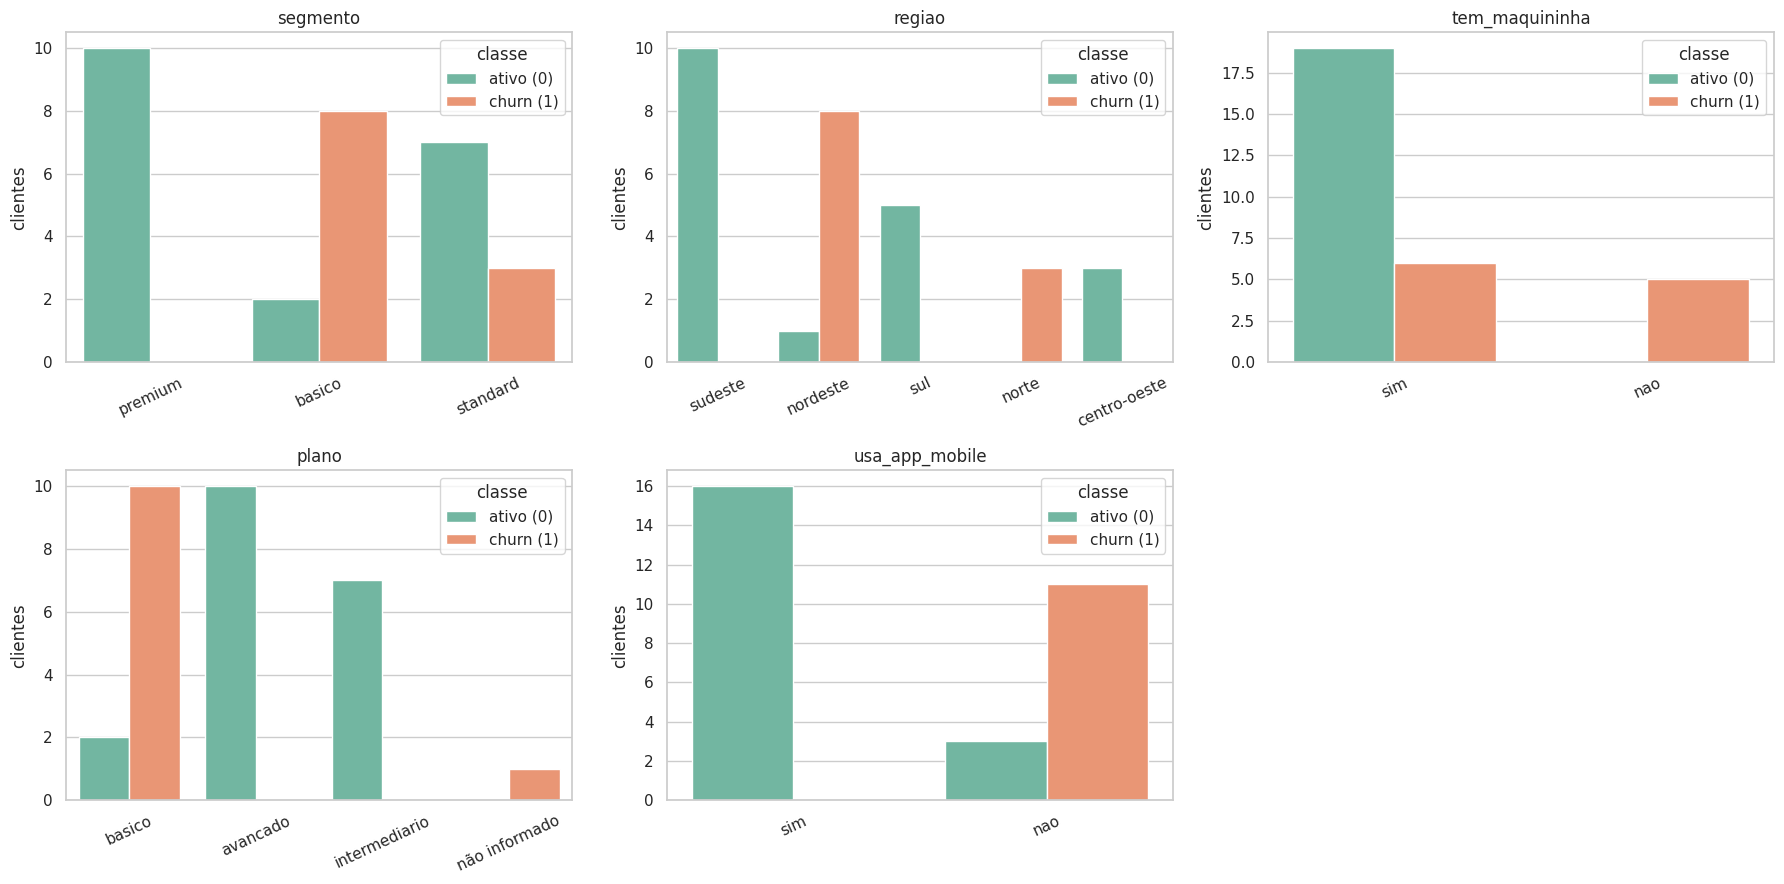

In [121]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()
plot_cat = plot_df.copy()
for col in cat_cols:
    plot_cat[col] = plot_cat[col].astype("object").where(plot_cat[col].notna(), "não informado")

for ax, col in zip(axes, cat_cols):
    ordem = plot_cat[col].value_counts(dropna=False).index
    sns.countplot(data=plot_cat, x=col, hue="classe", order=ordem, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("clientes")
    ax.tick_params(axis="x", rotation=25)

for ax in axes[len(cat_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


**Comentário:** algumas categorias também parecem importantes, como plano básico, não usar app mobile e não ter maquininha. Mas como temos poucos exemplos, isso ainda precisa ser confirmado pelo modelo.


## 4.2.6 Hipóteses para a modelagem

Depois da EDA, as variáveis que mais parecem ajudar a prever churn são:

- `dias_sem_transacao`: muitos dias parado pode indicar abandono;
- `variacao_tpv_3m`: queda no TPV mostra menor uso;
- `num_chamados_suporte`: muitos chamados podem indicar problema ou insatisfação;
- `nps_ultimo`: NPS baixo indica cliente insatisfeito;
- `num_produtos_ativos`: poucos produtos indicam menor vínculo com a Stone;
- `usa_app_mobile`, `tem_maquininha` e `plano`: mostram o nível de uso dos serviços.

Essas hipóteses vão guiar a etapa de modelagem.


# 4.3 — Modelagem Preditiva

**Objetivo:** treinar e comparar dois classificadores para prever `churn`.

**Metodologia:**

1. **Pré-processamento em Pipeline** — imputação, one-hot e padronização encapsulados, ajustados apenas no treino de cada fold (evita vazamento de dados).
2. **Validação cruzada estratificada (5 folds)** — com 30 linhas, um split fixo daria teste instável (~6 clientes). A validação cruzada testa cada cliente uma vez e usa a média dos folds como métrica confiável.
3. **Dois modelos:**
   - **Regressão Logística** — linear, interpretável, baseline sólido.
   - **Random Forest** — não-linear, captura interações entre variáveis.
4. **Métricas comparativas** — F1 e ROC-AUC (focadas na classe minoritária churn), com precision e recall para detalhar os erros.
5. **Matriz de confusão out-of-fold** — separa os dois tipos de erro (deixar churn passar vs. alarme falso).
6. **Otimização de hiperparâmetros (GridSearchCV)** — ajusta os parâmetros de cada modelo, justificando as escolhas.
7. **Interpretação** — quais variáveis pesam e qual modelo escolher para a etapa 4.4.

## 4.3.1 Pré-processamento pós-EDA

Encapsulamos as transformações num Pipeline. Cada ramo trata um tipo de coluna e o resultado é aplicado **dentro** da validação cruzada — ajustado só no treino de cada fold, sem vazamento.

In [122]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# X = features usadas na previsão; y = alvo (churn 0/1).
# Numéricas -> float (NaN nativo); categóricas -> object com NaN real.
# O Int64/string do pandas carrega pd.NA, que o sklearn não interpreta.
X = df[num_cols + cat_cols].copy()
X[num_cols] = X[num_cols].astype(float)
X[cat_cols] = X[cat_cols].astype(object).where(X[cat_cols].notna(), float("nan"))
y = df[alvo].astype(int)

# Ramo NUMÉRICO: imputa mediana (robusta a outliers, ver 4.2.3),
# depois padroniza (z-score) para que TPV não domine NPS pela escala.
ramo_numerico = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median")),
    ("padronizar", StandardScaler()),
])

# Ramo CATEGÓRICO: imputa moda (categoria mais frequente),
# depois One-Hot (uma coluna 0/1 por categoria, sem impor ordem inexistente).
ramo_categorico = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# ColumnTransformer aplica cada ramo às suas colunas e junta o resultado.
# Fica guardado como "receita": só roda de fato dentro da validação cruzada.
preprocessador = ColumnTransformer(transformers=[
    ("num", ramo_numerico, num_cols),
    ("cat", ramo_categorico, cat_cols),
])

## 4.3.2 Validação cruzada dos dois modelos

Cada modelo é um Pipeline `preprocessador + classificador`. Em cada uma das 5 rodadas, treina em 4 folds e é avaliado no fold de fora; coletamos 4 métricas por rodada e tiramos a média.

**Métricas:** F1 (equilíbrio entre pegar churns e evitar alarme falso — principal em base desbalanceada), ROC-AUC (capacidade de separar as classes), precision (dos marcados como churn, quantos eram) e recall (dos churns reais, quantos foram pegos).

`class_weight="balanced"` compensa o desbalanceamento (mais ativos que churns, ver 4.2.1).

In [123]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
import pandas as pd

# 5 folds estratificados: cada fold mantém a proporção churn/ativo da base.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cada modelo = Pipeline (preprocessador + classificador).
# O prep é reajustado no treino de cada fold, evitando vazamento.
modelos = {
    "Regressão Logística": Pipeline(steps=[
        ("prep", preprocessador),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocessador),
        ("clf", RandomForestClassifier(class_weight="balanced", random_state=42)),
    ]),
}

# Métricas: F1/ROC-AUC (visão geral) + precision/recall (detalham os erros).
metricas = ["f1", "roc_auc", "precision", "recall"]

# Roda a CV de cada modelo e guarda a média dos folds.
resultados = []
for nome, pipe in modelos.items():
    scores = cross_validate(pipe, X, y, cv=cv, scoring=metricas)
    resultados.append({
        "modelo": nome,
        **{m: scores[f"test_{m}"].mean().round(3) for m in metricas},
    })

comparativo = pd.DataFrame(resultados).set_index("modelo")
display(comparativo)

,f1,roc_auc,precision,recall
modelo,,,,
Regressão Logística,0.96,1.0,0.933,1.0
Random Forest,1.00,1.0,1.000,1.0


> **Limitação — métricas saturadas.** Com apenas 30 clientes, os modelos atingem F1 e ROC-AUC próximos de 1.0. Isso não indica qualidade real: a base é pequena e linearmente separável demais para diferenciar os modelos. Os resultados servem como prova de conceito, não como estimativa de desempenho em produção.

## 4.3.3 Matriz de confusão (out-of-fold)

Cada cliente é previsto quando está no fold de teste. Juntamos todas as previsões e montamos a matriz, separando os dois erros: churn não detectado (grave) vs. alarme falso (leve).

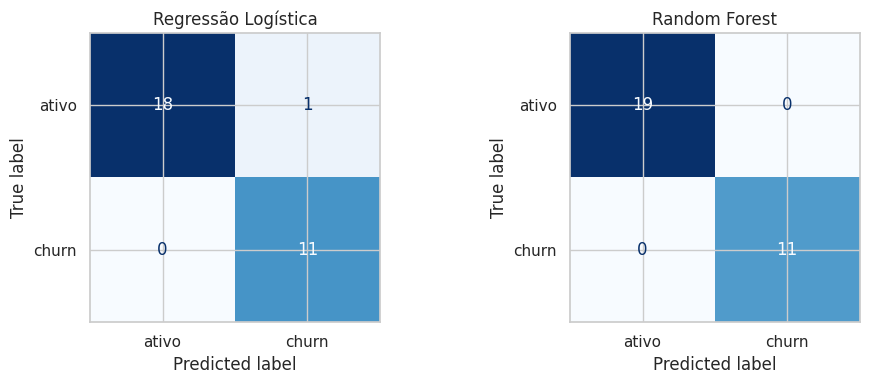

In [124]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(modelos), figsize=(10, 4))

for ax, (nome, pipe) in zip(axes, modelos.items()):
    # Previsão out-of-fold: cada linha é prevista quando está fora do seu treino.
    y_pred = cross_val_predict(pipe, X, y, cv=cv)
    ConfusionMatrixDisplay.from_predictions(
        y, y_pred, display_labels=["ativo", "churn"],
        cmap="Blues", ax=ax, colorbar=False,
    )
    ax.set_title(nome)

plt.tight_layout()
plt.show()

**Interpretação da matriz de confusão:**

- **Regressão Logística:** 18 ativos e 11 churns corretos; 1 ativo classificado como churn (alarme falso). Nenhum churn perdido.
- **Random Forest:** classificação perfeita — 19 ativos e 11 churns, sem erros.

O erro da Logística é do tipo menos grave (alarme falso: sinaliza risco em cliente que ficaria). O erro crítico — deixar passar um churn real — não ocorreu em nenhum modelo; ambos recuperam 100% dos churns (recall = 1.0).

**Como guia os próximos passos:** o desempenho quase idêntico confirma que a escolha do modelo para a etapa 4.4 não deve se basear em métrica, e sim em interpretabilidade.

## 4.3.4 Otimização de hiperparâmetros

GridSearchCV testa combinações dos principais parâmetros de cada modelo, usando a mesma validação cruzada estratificada. Otimizamos por F1 (foco na classe churn).

In [125]:
from sklearn.model_selection import GridSearchCV

# Grade de parâmetros por modelo. Prefixo "clf__" = etapa do Pipeline.
grades = {
    "Regressão Logística": {
        "clf__C": [0.01, 0.1, 1, 10],        # força da regularização
    },
    "Random Forest": {
        "clf__n_estimators": [100, 300],      # nº de árvores
        "clf__max_depth": [None, 3, 5],       # profundidade máxima
        "clf__min_samples_leaf": [1, 2],      # mínimo de amostras por folha
    },
}

# Para cada modelo, busca a melhor combinação e guarda o Pipeline já ajustado.
melhores = {}
for nome, pipe in modelos.items():
    busca = GridSearchCV(pipe, grades[nome], cv=cv, scoring="f1")
    busca.fit(X, y)
    melhores[nome] = busca.best_estimator_
    print(f"{nome}: F1={busca.best_score_:.3f} | {busca.best_params_}")

Regressão Logística: F1=0.960 | {'clf__C': 1}
Random Forest: F1=1.000 | {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}


**Interpretação da otimização:**

Os melhores parâmetros encontrados são valores simples (regularização moderada na Regressão Logística; árvores rasas na Random Forest), coerente com uma base de 30 linhas: modelos complexos não trazem ganho e só aumentam o risco de overfitting. A otimização não separou os modelos porque o problema é fácil demais para o tamanho da amostra — as métricas já estavam saturadas antes do ajuste.

**Decisão para a etapa 4.4:** escolhemos a **Regressão Logística** como modelo de referência. Mesmo com F1 ligeiramente menor, ela é interpretável — fornece coeficientes que indicam o peso de cada variável na previsão. Isso é essencial na geração de texto, onde a explicação precisa citar *por que* o cliente foi classificado como churn, alinhada às features que o modelo de fato usou.

# 4.4 — Geração de Texto: Tabular → Linguagem

Nesta etapa, usamos a previsão do modelo para gerar uma explicação curta em linguagem natural.

A primeira abordagem é por **Template**. Ela usa regras simples baseadas na EDA: dias sem transação, queda de TPV, chamados de suporte, NPS, produtos ativos, uso do app, maquininha e plano.

A vantagem do template é que ele não inventa informação: a frase só usa dados que existem na linha do cliente.

## 4.4.1 Preparação para prever um cliente

A função abaixo recebe uma linha do `df`, prepara no mesmo formato usado pelo modelo e retorna a previsão de churn com a probabilidade.

In [126]:
# Modelo escolhido na etapa 4.3: Regressão Logística pela interpretabilidade.
modelo_texto = melhores["Regressão Logística"]


def preparar_cliente_para_modelo(cliente):
    """Transforma uma linha do df em DataFrame aceito pelo Pipeline."""
    entrada = pd.DataFrame([cliente[num_cols + cat_cols].to_dict()])
    entrada[num_cols] = entrada[num_cols].astype(float)
    entrada[cat_cols] = entrada[cat_cols].astype(object).where(
        entrada[cat_cols].notna(),
        float("nan")
    )
    return entrada


def prever_churn_cliente(cliente, modelo=modelo_texto):
    """Retorna classe prevista e probabilidade de churn."""
    entrada = preparar_cliente_para_modelo(cliente)
    prob_churn = modelo.predict_proba(entrada)[0, 1]
    predicao = int(prob_churn >= 0.5)
    return predicao, prob_churn

## 4.4.2 Seleção dos fatores para a explicação

Aqui eu separo fatores de risco e fatores de proteção. Para clientes com previsão de churn, o texto prioriza os fatores de risco. Para clientes com baixa chance de churn, o texto prioriza sinais positivos.

In [127]:
def pct(valor, absoluto=False):
    """Formata número como percentual."""
    if pd.isna(valor):
        return "não informado"
    valor = float(valor)
    if absoluto:
        valor = abs(valor)
    return f"{valor:.0%}"


def inteiro(valor):
    """Formata número inteiro vindo do pandas, tratando ausentes."""
    if pd.isna(valor):
        return "não informado"
    return int(valor)


def texto_categoria(cliente, coluna):
    """Lê categoria como texto e evita erro quando o valor é ausente."""
    valor = cliente[coluna]
    if pd.isna(valor):
        return None
    return str(valor)


def plural(qtd, singular, plural):
    return singular if int(qtd) == 1 else plural


def selecionar_fatores_template(cliente, predicao):
    riscos = []
    protecoes = []

    dias = cliente["dias_sem_transacao"]
    if pd.notna(dias):
        if dias >= 14:
            qtd_dias = inteiro(dias)
            riscos.append(f"{qtd_dias} {plural(qtd_dias, 'dia', 'dias')} sem transação")
        elif dias <= 5:
            qtd_dias = inteiro(dias)
            protecoes.append(f"apenas {qtd_dias} {plural(qtd_dias, 'dia', 'dias')} sem transação")

    variacao_tpv = cliente["variacao_tpv_3m"]
    if pd.notna(variacao_tpv):
        if variacao_tpv <= -0.30:
            riscos.append(f"queda de {pct(variacao_tpv, absoluto=True)} no TPV em 3 meses")
        elif variacao_tpv >= 0:
            protecoes.append(f"crescimento de {pct(variacao_tpv)} no TPV em 3 meses")

    chamados = cliente["num_chamados_suporte"]
    if pd.notna(chamados):
        if chamados >= 4:
            qtd_chamados = inteiro(chamados)
            riscos.append(f"{qtd_chamados} {plural(qtd_chamados, 'chamado', 'chamados')} de suporte")
        elif chamados <= 1:
            qtd_chamados = inteiro(chamados)
            protecoes.append(f"baixo volume de suporte ({qtd_chamados} {plural(qtd_chamados, 'chamado', 'chamados')})")

    nps = cliente["nps_ultimo"]
    if pd.notna(nps):
        if nps <= 4:
            riscos.append(f"NPS baixo ({inteiro(nps)})")
        elif nps >= 8:
            protecoes.append(f"NPS alto ({inteiro(nps)})")

    produtos = cliente["num_produtos_ativos"]
    if pd.notna(produtos):
        if produtos <= 1:
            riscos.append("apenas 1 produto ativo")
        elif produtos >= 3:
            protecoes.append(f"{inteiro(produtos)} produtos ativos")

    app = texto_categoria(cliente, "usa_app_mobile")
    if app == "nao":
        riscos.append("não usa o app mobile")
    elif app == "sim":
        protecoes.append("usa o app mobile")

    maquininha = texto_categoria(cliente, "tem_maquininha")
    if maquininha == "nao":
        riscos.append("não possui maquininha")
    elif maquininha == "sim":
        protecoes.append("possui maquininha")

    plano = texto_categoria(cliente, "plano")
    if plano == "basico":
        riscos.append("plano básico")
    elif plano in ["intermediario", "avancado"]:
        protecoes.append(f"plano {plano}")

    if predicao == 1:
        return riscos[:3] if riscos else ["sinais de risco identificados pelo modelo"]
    return protecoes[:3] if protecoes else ["não há sinais fortes de risco nos dados analisados"]

## 4.4.3 Geração da explicação por Template

A função final junta a previsão, a probabilidade e os fatores selecionados em uma frase curta para o time de retenção.

In [128]:
def gerar_explicacao_template(cliente, modelo=modelo_texto):
    predicao, prob_churn = prever_churn_cliente(cliente, modelo)
    fatores = selecionar_fatores_template(cliente, predicao)
    texto_fatores = "; ".join(fatores)

    if predicao == 1:
        return (
            f"Cliente com alto risco de churn ({prob_churn:.0%}). "
            f"Principais sinais: {texto_fatores}."
        )

    return (
        f"Cliente com baixo risco de churn ({prob_churn:.0%}). "
        f"Principais sinais positivos: {texto_fatores}."
    )

## 4.4.4 Exemplos de saída

O enunciado pede exemplos para pelo menos 10 clientes. A tabela abaixo mostra a previsão do modelo e a explicação gerada pelo template.

In [129]:
exemplos_template = []

for idx, cliente in df.head(10).iterrows():
    predicao, prob_churn = prever_churn_cliente(cliente, modelo_texto)
    exemplos_template.append({
        "cliente": idx + 1,
        "churn_real": int(cliente[alvo]),
        "predicao_modelo": predicao,
        "prob_churn": round(prob_churn, 3),
        "explicacao_template": gerar_explicacao_template(cliente, modelo_texto),
    })

exemplos_template = pd.DataFrame(exemplos_template)
display(exemplos_template)

,cliente,churn_real,predicao_modelo,prob_churn,explicacao_template
0,1,0,0,0.005,Cliente com baixo risco de churn (1%). Princip...
1,2,1,1,0.955,Cliente com alto risco de churn (96%). Princip...
2,3,0,0,0.036,Cliente com baixo risco de churn (4%). Princip...
3,4,0,0,0.001,Cliente com baixo risco de churn (0%). Princip...
4,5,1,1,0.980,Cliente com alto risco de churn (98%). Princip...
5,6,1,1,0.847,Cliente com alto risco de churn (85%). Princip...
6,7,0,0,0.006,Cliente com baixo risco de churn (1%). Princip...
7,8,0,0,0.273,Cliente com baixo risco de churn (27%). Princi...
8,9,0,0,0.000,Cliente com baixo risco de churn (0%). Princip...
9,10,1,1,0.994,Cliente com alto risco de churn (99%). Princip...


**Comentário:** o template é simples, mas é fácil de auditar. Ele é uma boa primeira abordagem porque explica a previsão usando sinais claros do próprio dataset, sem criar informações externas.

## 4.4.5 Abordagem com Hugging Face — Qwen2.5 0.5B Instruct

A segunda abordagem usa um modelo de linguagem do Hugging Face para gerar a explicação automaticamente.

O modelo escolhido foi `Qwen/Qwen2.5-0.5B-Instruct`, porque:

- não precisa de token;
- é pequeno para um LLM, com cerca de 0.5B parâmetros;
- é uma versão *Instruct*, feita para seguir comandos;
- tem licença Apache 2.0;
- suporta português.

Esta abordagem usa **prompt engineering**, sem fine-tuning. Como o dataset tem apenas 30 clientes, não faz sentido treinar um modelo gerador do zero.

### Carregamento do modelo

A célula abaixo carrega o Qwen pelo Hugging Face. Na primeira execução, o download pode demorar porque o modelo precisa ser baixado.

In [130]:
import importlib.util
import subprocess
import sys
from importlib import metadata

# Dependências usadas pelo Qwen. O modelo não precisa de token.
deps_qwen = {
    "torch": "torch",
    "transformers": "transformers>=4.37.0",
    "accelerate": "accelerate",
    "packaging": "packaging",
}

faltantes_qwen = [pacote for modulo, pacote in deps_qwen.items() if importlib.util.find_spec(modulo) is None]
if faltantes_qwen:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltantes_qwen])

from packaging.version import parse

# Qwen2.5 precisa de transformers >= 4.37.0.
versao_transformers = metadata.version("transformers")
if parse(versao_transformers) < parse("4.37.0"):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "transformers>=4.37.0"])

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

MODELO_QWEN = "Qwen/Qwen2.5-0.5B-Instruct"

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
tipo_tensor = torch.float16 if dispositivo == "cuda" else torch.float32

tokenizer_qwen = AutoTokenizer.from_pretrained(MODELO_QWEN)
model_qwen = AutoModelForCausalLM.from_pretrained(
    MODELO_QWEN,
    torch_dtype=tipo_tensor,
)
model_qwen = model_qwen.to(dispositivo)
model_qwen.eval()

print(f"Modelo carregado: {MODELO_QWEN}")
print(f"Dispositivo: {dispositivo}")


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Modelo carregado: Qwen/Qwen2.5-0.5B-Instruct
Dispositivo: cpu


### Prompt usado no Qwen

O prompt recebe os mesmos fatores usados pelo template. Isso ajuda a controlar a resposta e reduz o risco de o LLM inventar informações.

In [131]:
def montar_prompt_qwen(cliente, modelo=modelo_texto):
    predicao, prob_churn = prever_churn_cliente(cliente, modelo)
    fatores = selecionar_fatores_template(cliente, predicao)
    classe = "alto risco de churn" if predicao == 1 else "baixo risco de churn"

    mensagens = [
        {
            "role": "system",
            "content": (
                "Você escreve explicações curtas para um analista de retenção. "
                "Responda em português do Brasil, em uma única frase. "
                "Use somente os dados fornecidos e não invente informações."
            ),
        },
        {
            "role": "user",
            "content": (
                f"Previsão do modelo: {classe}.\n"
                f"Probabilidade de churn: {prob_churn:.0%}.\n"
                f"Fatores principais: {'; '.join(fatores)}.\n"
                "Explique o motivo da previsão de forma clara e curta."
            ),
        },
    ]

    return tokenizer_qwen.apply_chat_template(
        mensagens,
        tokenize=False,
        add_generation_prompt=True,
    )


def limpar_resposta_qwen(texto):
    texto = texto.strip().replace("\n", " ")
    return " ".join(texto.split())

### Função de geração com Qwen

A função abaixo gera uma explicação usando o Qwen. O limite de tokens mantém a resposta curta.

In [132]:
def gerar_explicacao_qwen(cliente, modelo=modelo_texto):
    prompt = montar_prompt_qwen(cliente, modelo)

    entradas = tokenizer_qwen([prompt], return_tensors="pt").to(model_qwen.device)

    with torch.no_grad():
        saida_ids = model_qwen.generate(
            **entradas,
            max_new_tokens=80,
            do_sample=False,
            pad_token_id=tokenizer_qwen.eos_token_id,
        )

    # Remove o prompt da saída, deixando só o texto gerado.
    novos_tokens = saida_ids[0][entradas.input_ids.shape[-1]:]
    resposta = tokenizer_qwen.decode(novos_tokens, skip_special_tokens=True)
    return limpar_resposta_qwen(resposta)

### Exemplos com Template e Qwen

A tabela compara a explicação do template com a explicação gerada pelo Qwen para os 10 primeiros clientes.

In [133]:
exemplos_qwen = []

for idx, cliente in df.head(10).iterrows():
    predicao, prob_churn = prever_churn_cliente(cliente, modelo_texto)
    exemplos_qwen.append({
        "cliente": idx + 1,
        "churn_real": int(cliente[alvo]),
        "predicao_modelo": predicao,
        "prob_churn": round(prob_churn, 3),
        "explicacao_template": gerar_explicacao_template(cliente, modelo_texto),
        "explicacao_qwen": gerar_explicacao_qwen(cliente, modelo_texto),
    })

exemplos_qwen = pd.DataFrame(exemplos_qwen)
display(
    exemplos_qwen.style.set_properties(
        subset=["explicacao_template", "explicacao_qwen"],
        **{
            "white-space": "pre-wrap",
            "text-align": "left",
            "max-width": "600px",
        }
    )
)

,cliente,churn_real,predicao_modelo,prob_churn,explicacao_template,explicacao_qwen
0,1,0,0,0.005000,Cliente com baixo risco de churn (1%). Principais sinais positivos: apenas 2 dias sem transação; baixo volume de suporte (1 chamado); NPS alto (9).,"A previsão de churn é baixa porque a probabilidade é de 1%, com fatores como apenas 2 dias sem transação e baixo volume de suporte elevando o NPS ao nível de 9%."
1,2,1,1,0.955000,Cliente com alto risco de churn (96%). Principais sinais: 18 dias sem transação; queda de 45% no TPV em 3 meses; 5 chamados de suporte.,"O modelo prevê alta probabilidade de chamar clientes após 18 dias sem transações, com queda de 45% na taxa de conversão em três meses. Estes fatores são considerados importantes pela análise de retenção."
2,3,0,0,0.036000,Cliente com baixo risco de churn (4%). Principais sinais positivos: apenas 5 dias sem transação; usa o app mobile; possui maquininha.,"A previsão de churn é baixa porque a probabilidade de chamar-se-chorar é de 4%, enquanto os fatores principais são apenas 5 dias sem transações e uso do aplicativo móvel."
3,4,0,0,0.001000,Cliente com baixo risco de churn (0%). Principais sinais positivos: apenas 1 dia sem transação; crescimento de 8% no TPV em 3 meses; baixo volume de suporte (0 chamados).,"A previsão de churn é baixa porque a probabilidade de chamar é zero, indicando que o cliente está seguro. Os fatores principais incluem apenas um dia sem transação e crescimento de 8% no número de chamadas em três meses, enquanto o volume de suporte é baixo."
4,5,1,1,0.980000,Cliente com alto risco de churn (98%). Principais sinais: 22 dias sem transação; queda de 52% no TPV em 3 meses; 6 chamados de suporte.,"O modelo prevê alta probabilidade de chamar clientes após 22 dias sem transações, com queda de 52% na taxa de conversão em três meses. Estes fatores são considerados importantes pela análise de retenção."
5,6,1,1,0.847000,Cliente com alto risco de churn (85%). Principais sinais: queda de 30% no TPV em 3 meses; 4 chamados de suporte; NPS baixo (4).,"A previsão de churn é alta porque a queda na taxa de troca de serviços (TPV) foi de 30%, o número de chamadas de suporte aumentou para 4, e o NPS (Nível de Satisfaction por Cliente) está abaixo de 4."
6,7,0,0,0.006000,Cliente com baixo risco de churn (1%). Principais sinais positivos: apenas 3 dias sem transação; crescimento de 3% no TPV em 3 meses; baixo volume de suporte (1 chamado).,"A previsão de churn é baixa porque a probabilidade de churn é de 1%, e os fatores principais incluem apenas 3 dias sem transação e crescimento de 3% no número de usuários no período de 3 meses."
7,8,0,0,0.273000,Cliente com baixo risco de churn (27%). Principais sinais positivos: possui maquininha.,A previsão de que o cliente terá chutado é considerada baixa porvido a chance de ocorrer. O fator principal é a presença de maquininha no sistema.
8,9,0,0,0.000000,Cliente com baixo risco de churn (0%). Principais sinais positivos: apenas 1 dia sem transação; crescimento de 12% no TPV em 3 meses; baixo volume de suporte (0 chamados).,"A previsão de churn é baixa porque a probabilidade de chamar é zero, indicando que o cliente está seguro. Os fatores principais incluem apenas um dia sem transação e crescimento de 12% no número de chamadas em três meses, enquanto o volume de suporte é baixo."
9,10,1,1,0.994000,Cliente com alto risco de churn (99%). Principais sinais: 25 dias sem transação; queda de 58% no TPV em 3 meses; 7 chamados de suporte.,"O modelo prevê alta probabilidade de chamar clientes após 25 dias sem transações, com queda de 58% na taxa de conversão em três meses. Estes fatores são considerados importantes pela previsão de churn alto."


**Comentário:** o Qwen pode gerar frases mais naturais que o template, mas o template tende a ser mais previsível e fácil de auditar. Por isso, na avaliação da seção 5, devemos comparar principalmente fidelidade aos dados, clareza e utilidade da explicação.

# 5 — Avaliação da Qualidade do Texto

Nesta seção avaliamos se as explicações geradas são úteis para um analista de retenção.

A avaliação usa três critérios simples:

- **Coerência:** o texto é claro e fácil de entender?
- **Completude:** o texto cita fatores suficientes para justificar a previsão?
- **Fidelidade:** o texto usa apenas informações presentes nos dados, sem inventar fatos?

Como o dataset é pequeno, a avaliação é feita em uma amostra de 10 clientes, os mesmos usados nos exemplos da seção 4.4.

## 5.1 Rubrica de avaliação

A rubrica abaixo define notas de 1 a 5. Ela serve como guia para comparar o template e o Qwen.

In [134]:
rubrica_texto = pd.DataFrame([
    {
        "nota": 1,
        "nivel": "Ruim",
        "descricao": "Texto confuso, muito incompleto ou com informação inventada.",
    },
    {
        "nota": 3,
        "nivel": "Aceitável",
        "descricao": "Texto compreensível, mas genérico ou com poucos fatores.",
    },
    {
        "nota": 5,
        "nivel": "Bom",
        "descricao": "Texto claro, útil e fiel aos dados do cliente.",
    },
])

display(rubrica_texto)

,nota,nivel,descricao
0,1,Ruim,"Texto confuso, muito incompleto ou com informa..."
1,3,Aceitável,"Texto compreensível, mas genérico ou com pouco..."
2,5,Bom,"Texto claro, útil e fiel aos dados do cliente."


## 5.2 Base para avaliação das explicações

A tabela completa com as explicações já foi mostrada na seção 4.4.5. Aqui apenas reaproveitamos esses dados para calcular a rubrica da seção 5, evitando repetir o mesmo display.


In [ ]:
# Usa a tabela com Qwen se ela existir; caso contrário, usa só o template.
if "exemplos_qwen" in globals():
    avaliacao_base = exemplos_qwen.copy()
else:
    avaliacao_base = exemplos_template.copy()
    avaliacao_base["explicacao_qwen"] = "Qwen não executado nesta sessão."

colunas_avaliacao = [
    "cliente",
    "churn_real",
    "predicao_modelo",
    "prob_churn",
    "explicacao_template",
    "explicacao_qwen",
]

avaliacao_texto = avaliacao_base[colunas_avaliacao].copy()
print(f"Base de avaliação preparada com {len(avaliacao_texto)} clientes.")


,cliente,churn_real,predicao_modelo,prob_churn,explicacao_template,explicacao_qwen
0,1,0,0,0.005,Cliente com baixo risco de churn (1%). Princip...,A previsão de churn é baixa porque a probabili...
1,2,1,1,0.955,Cliente com alto risco de churn (96%). Princip...,O modelo prevê alta probabilidade de chamar cl...
2,3,0,0,0.036,Cliente com baixo risco de churn (4%). Princip...,A previsão de churn é baixa porque a probabili...
3,4,0,0,0.001,Cliente com baixo risco de churn (0%). Princip...,A previsão de churn é baixa porque a probabili...
4,5,1,1,0.980,Cliente com alto risco de churn (98%). Princip...,O modelo prevê alta probabilidade de chamar cl...
5,6,1,1,0.847,Cliente com alto risco de churn (85%). Princip...,A previsão de churn é alta porque a queda na t...
6,7,0,0,0.006,Cliente com baixo risco de churn (1%). Princip...,A previsão de churn é baixa porque a probabili...
7,8,0,0,0.273,Cliente com baixo risco de churn (27%). Princi...,A previsão de que o cliente terá chutado é con...
8,9,0,0,0.000,Cliente com baixo risco de churn (0%). Princip...,A previsão de churn é baixa porque a probabili...
9,10,1,1,0.994,Cliente com alto risco de churn (99%). Princip...,O modelo prevê alta probabilidade de chamar cl...


## 5.3 Avaliação assistida por regras

Para deixar a análise reproduzível, uso uma pontuação simples baseada em regras. Ela não substitui uma avaliação humana, mas ajuda a comparar as abordagens de forma organizada.

A ideia é:

- textos muito curtos ou muito longos perdem coerência;
- textos que citam mais fatores relevantes ganham completude;
- textos que mencionam assuntos fora do problema, como crédito ou inadimplência, perdem fidelidade.

In [136]:
PALAVRAS_FATORES = {
    "dias_sem_transacao": ["dia", "dias", "transação", "transacionar"],
    "tpv": ["tpv", "volume"],
    "suporte": ["suporte", "chamado", "chamados"],
    "nps": ["nps"],
    "produtos": ["produto", "produtos"],
    "app": ["app", "mobile"],
    "maquininha": ["maquininha"],
    "plano": ["plano"],
}

TERMOS_FORA_DO_CONTEXTO = ["inadimpl", "crédito", "emprestimo", "empréstimo", "score de crédito"]


def contar_fatores_no_texto(texto):
    texto = str(texto).lower()
    encontrados = []
    for fator, palavras in PALAVRAS_FATORES.items():
        if any(palavra in texto for palavra in palavras):
            encontrados.append(fator)
    return encontrados


def pontuar_texto(texto):
    texto = str(texto)
    texto_lower = texto.lower()
    palavras = texto.split()
    fatores = contar_fatores_no_texto(texto)

    # Coerência: frase curta, legível e sem exagerar no tamanho.
    if 10 <= len(palavras) <= 70:
        coerencia = 5
    elif 6 <= len(palavras) <= 90:
        coerencia = 4
    else:
        coerencia = 2

    # Completude: quantidade de fatores citados.
    if len(fatores) >= 3:
        completude = 5
    elif len(fatores) == 2:
        completude = 4
    elif len(fatores) == 1:
        completude = 3
    else:
        completude = 2

    # Fidelidade: penaliza termos fora do problema.
    if "não executado" in texto_lower:
        fidelidade = 0
    elif any(termo in texto_lower for termo in TERMOS_FORA_DO_CONTEXTO):
        fidelidade = 2
    else:
        fidelidade = 5

    return coerencia, completude, fidelidade, "; ".join(fatores)


linhas_avaliadas = []
for _, linha in avaliacao_texto.iterrows():
    for abordagem, coluna in [
        ("Template", "explicacao_template"),
        ("Qwen", "explicacao_qwen"),
    ]:
        coerencia, completude, fidelidade, fatores = pontuar_texto(linha[coluna])
        if fidelidade == 0:
            media = None
        else:
            media = round((coerencia + completude + fidelidade) / 3, 2)

        linhas_avaliadas.append({
            "cliente": linha["cliente"],
            "abordagem": abordagem,
            "coerencia": coerencia,
            "completude": completude,
            "fidelidade": fidelidade,
            "media": media,
            "fatores_identificados": fatores,
        })

avaliacao_regras = pd.DataFrame(linhas_avaliadas)
display(avaliacao_regras)

,cliente,abordagem,coerencia,completude,fidelidade,media,fatores_identificados
0,1,Template,5,5,5,5.00,dias_sem_transacao; tpv; suporte; nps
1,1,Qwen,5,5,5,5.00,dias_sem_transacao; tpv; suporte; nps
2,2,Template,5,5,5,5.00,dias_sem_transacao; tpv; suporte
3,2,Qwen,5,3,5,4.33,dias_sem_transacao
4,3,Template,5,5,5,5.00,dias_sem_transacao; app; maquininha
5,3,Qwen,5,3,5,4.33,dias_sem_transacao
6,4,Template,5,5,5,5.00,dias_sem_transacao; tpv; suporte
7,4,Qwen,5,5,5,5.00,dias_sem_transacao; tpv; suporte
8,5,Template,5,5,5,5.00,dias_sem_transacao; tpv; suporte
9,5,Qwen,5,3,5,4.33,dias_sem_transacao


## 5.4 Comparação entre abordagens

Agora calculamos a média das notas por abordagem. Se o Qwen não foi executado, ele aparece sem média válida.

In [137]:
comparacao_texto = (
    avaliacao_regras
    .dropna(subset=["media"])
    .groupby("abordagem")[["coerencia", "completude", "fidelidade", "media"]]
    .mean()
    .round(2)
)

display(comparacao_texto)

,coerencia,completude,fidelidade,media
abordagem,,,,
Qwen,5.0,3.8,5.0,4.60
Template,5.0,4.8,5.0,4.93


## 5.5 Exemplos bons e pontos de atenção

A célula abaixo separa exemplos com maior e menor nota média para facilitar a análise crítica.

In [138]:
avaliacao_com_texto = avaliacao_regras.merge(
    avaliacao_texto[["cliente", "explicacao_template", "explicacao_qwen"]],
    on="cliente",
    how="left",
)

melhores_exemplos = avaliacao_com_texto.dropna(subset=["media"]).sort_values("media", ascending=False).head(3)
piores_exemplos = avaliacao_com_texto.dropna(subset=["media"]).sort_values("media", ascending=True).head(3)

print("Melhores exemplos pela rubrica:")
display(melhores_exemplos)

print("Pontos de atenção pela rubrica:")
display(piores_exemplos)

Melhores exemplos pela rubrica:


,cliente,abordagem,coerencia,completude,fidelidade,media,fatores_identificados,explicacao_template,explicacao_qwen
0,1,Template,5,5,5,5.0,dias_sem_transacao; tpv; suporte; nps,Cliente com baixo risco de churn (1%). Princip...,A previsão de churn é baixa porque a probabili...
1,1,Qwen,5,5,5,5.0,dias_sem_transacao; tpv; suporte; nps,Cliente com baixo risco de churn (1%). Princip...,A previsão de churn é baixa porque a probabili...
2,2,Template,5,5,5,5.0,dias_sem_transacao; tpv; suporte,Cliente com alto risco de churn (96%). Princip...,O modelo prevê alta probabilidade de chamar cl...


Pontos de atenção pela rubrica:


,cliente,abordagem,coerencia,completude,fidelidade,media,fatores_identificados,explicacao_template,explicacao_qwen
3,2,Qwen,5,3,5,4.33,dias_sem_transacao,Cliente com alto risco de churn (96%). Princip...,O modelo prevê alta probabilidade de chamar cl...
5,3,Qwen,5,3,5,4.33,dias_sem_transacao,Cliente com baixo risco de churn (4%). Princip...,A previsão de churn é baixa porque a probabili...
15,8,Qwen,5,3,5,4.33,maquininha,Cliente com baixo risco de churn (27%). Princi...,A previsão de que o cliente terá chutado é con...


## 5.6 Análise crítica

O **template** é mais previsível e mais fácil de auditar, porque usa regras fixas baseadas nas variáveis do cliente. Isso reduz o risco de inventar informação. A desvantagem é que os textos podem ficar repetitivos.

O **Qwen** pode gerar frases mais naturais, mas precisa de controle. Por isso o prompt recebe a previsão, a probabilidade e os fatores já selecionados pelo template. Mesmo assim, a saída deve ser revisada para garantir que não inventou dados.

Para este trabalho, a melhor solução é uma abordagem híbrida: usar regras para escolher os fatores principais e usar o LLM apenas para melhorar a fluidez da frase. Assim, a explicação continua fiel aos dados e fica mais legível para o analista de retenção.